# Word 2 Vec

In [54]:
import pandas as pd
import numpy as np
import torch
from torch import nn
from sklearn.metrics import accuracy_score
import math
import random
import re
import string
from collections import defaultdict
from collections import Counter
import matplotlib.pyplot as plt

In [55]:
splits = {'train': 'train.parquet', 'validation': 'validation.parquet', 'test': 'test.parquet'}
train_df = pd.read_parquet("hf://datasets/cornell-movie-review-data/rotten_tomatoes/" + splits["train"])
test_df = pd.read_parquet("hf://datasets/cornell-movie-review-data/rotten_tomatoes/" + splits["test"])

In [57]:
def tokenize(text):
    return re.findall(r"\b\w+\b", text.lower().translate(str.maketrans('', '', string.punctuation)))

In [58]:
tokens = [tokenize(t) for t in train_df["text"]]

In [60]:
flat_tokens = [w for sent in tokens for w in sent]
word_counts = Counter(flat_tokens)
vocab = sorted(word_counts.keys())
word_to_id = {w: i for i, w in enumerate(vocab)}
id_to_word = {i: w for w, i in word_to_id.items()}
vocab_size = len(vocab)

In [61]:
print(f"words vocab size = {vocab_size}")

words vocab size = 18221


In [62]:
EMBEDDING_SIZE = 10
CONTEXT_WINDOW_SIZE = 1
NEGATIVES_PER_POSITIVE = 2

In [63]:
def generate_skipgram_pairs(k):
    pairs = set()
    word_context_map = defaultdict(set)
    for sentence in tokens:
        ids = [word_to_id[w] for w in sentence if w in word_to_id]
        for i, center in enumerate(ids):
            # context window
            start = max(0, i - k)
            end = min(len(ids), i + k + 1)
            for j in range(start, end):
                if i == j:
                    continue
                pairs.add((center, ids[j]))
                word_context_map[center].add(ids[j])
    return pairs, word_context_map

In [64]:
pairs, word_context_map = generate_skipgram_pairs(k=CONTEXT_WINDOW_SIZE)
print("Example pairs:", list(pairs)[:10])
print("Total pairs:", len(pairs))

Example pairs: [(11045, 10374), (6255, 5860), (8557, 384), (17858, 14915), (12453, 11037), (12880, 3934), (14926, 747), (6255, 9243), (11762, 16781), (11409, 8557)]
Total pairs: 169315


In [65]:
def sample_negative_words(word_idx, n):
    negatives = set()
    context_words = word_context_map[word_idx]
    while len(negatives) < n:
        neg = random.randint(0, vocab_size - 1)
        if neg not in context_words:
            negatives.add(neg)
    return negatives

In [66]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [67]:
rng = np.random.default_rng(42)
V_in = rng.uniform(-0.5, 0.5, (vocab_size, EMBEDDING_SIZE))  # input embeddings
U_out = rng.uniform(-0.5, 0.5, (vocab_size, EMBEDDING_SIZE)) # output embeddings

In [68]:
#super inefficient
def train_skipgram_step(center_id, context_ids, lr):
    v_c = V_in[center_id]
    grad_v = np.zeros_like(v_c)

    for ctx in context_ids:
        u_o = U_out[ctx]
        s_pos = np.dot(v_c, u_o)
        p_pos = sigmoid(s_pos)
        g_pos = 1 - p_pos
        grad_v += g_pos * u_o
        U_out[ctx] += lr * g_pos * v_c

    # negatives
    n_negatives = math.ceil(len(context_ids) * NEGATIVES_PER_POSITIVE)
    neg_ids = sample_negative_words(center_id, n_negatives)
    for n_id in neg_ids:
        u_n = U_out[n_id]
        s_neg = np.dot(v_c, u_n)
        p_neg = sigmoid(s_neg)
        g_neg = -p_neg
        grad_v += g_neg * u_n
        U_out[n_id] += lr * g_neg * v_c

    V_in[center_id] += lr * grad_v

In [69]:
def train_skipgram_vectorized_step(center_id, context_ids: list, lr):
    v_c = V_in[center_id]

    # positive
    U_pos_vec = U_out[context_ids]
    g_pos_vec = (1 - sigmoid(np.dot(U_pos_vec, v_c)))[:, np.newaxis] / len(context_ids)
    grad_v_pos_vec = np.sum(g_pos_vec * U_pos_vec, axis=0)
    U_out[context_ids] += lr * g_pos_vec * v_c[np.newaxis, :]

    # negative
    n_negatives = math.ceil(len(context_ids) * NEGATIVES_PER_POSITIVE)
    neg_ids = list(sample_negative_words(center_id, n_negatives))

    U_neg_vec = U_out[neg_ids]
    g_neg_vec = (-sigmoid(np.dot(U_neg_vec, v_c)))[:, np.newaxis] / len(neg_ids)
    grad_v_neg_vec = np.sum(g_neg_vec * U_neg_vec, axis=0)
    U_out[neg_ids] += lr * g_neg_vec * v_c[np.newaxis, :]

    V_in[center_id] += lr * (grad_v_pos_vec + grad_v_neg_vec)

In [70]:
V_history = []

In [71]:
def train_skipgram(lr=0.1, epochs=1):
    pair_list = list(pairs)
    for epoch in range(epochs):
        V_history.append(V_in.copy())

        np.random.shuffle(pair_list)
        i = 0
        for center, context in pair_list:
            if i % 10_000 == 0:
                print(f"pair # {i + 1} / {len(pair_list)}")
            train_skipgram_step(center, [context], lr)
            i += 1
        print(f"Epoch {epoch+1}/{epochs} done")

In [72]:
def train_skipgram_vectorized(lr=0.1, epochs=1):
    for epoch in range(epochs):
        V_history.append(V_in.copy())

        for center, context in word_context_map.items():
            train_skipgram_vectorized_step(center, list(context), lr)
        print(f"Epoch {epoch+1}/{epochs} done")

In [98]:
train_skipgram_vectorized(epochs=100, lr=0.1)

Epoch 1/100 done
Epoch 2/100 done
Epoch 3/100 done
Epoch 4/100 done
Epoch 5/100 done
Epoch 6/100 done
Epoch 7/100 done
Epoch 8/100 done
Epoch 9/100 done
Epoch 10/100 done
Epoch 11/100 done
Epoch 12/100 done
Epoch 13/100 done
Epoch 14/100 done
Epoch 15/100 done
Epoch 16/100 done
Epoch 17/100 done
Epoch 18/100 done
Epoch 19/100 done
Epoch 20/100 done
Epoch 21/100 done
Epoch 22/100 done
Epoch 23/100 done
Epoch 24/100 done
Epoch 25/100 done
Epoch 26/100 done
Epoch 27/100 done
Epoch 28/100 done
Epoch 29/100 done
Epoch 30/100 done
Epoch 31/100 done
Epoch 32/100 done
Epoch 33/100 done
Epoch 34/100 done
Epoch 35/100 done
Epoch 36/100 done
Epoch 37/100 done
Epoch 38/100 done
Epoch 39/100 done
Epoch 40/100 done
Epoch 41/100 done
Epoch 42/100 done
Epoch 43/100 done
Epoch 44/100 done
Epoch 45/100 done
Epoch 46/100 done
Epoch 47/100 done
Epoch 48/100 done
Epoch 49/100 done
Epoch 50/100 done
Epoch 51/100 done
Epoch 52/100 done
Epoch 53/100 done
Epoch 54/100 done
Epoch 55/100 done
Epoch 56/100 done
E

# Visualization

In [76]:
from sklearn.decomposition import PCA

In [89]:
sample_words = ["film", "movie", "movies", "rock", "wood", "woman", "man", "like", "enjoyment", "joy", "fun", "great", "common", "weird"]

In [90]:
def show_words_plot(words, embeddings):
    sample_embeddings = []
    labels = []
    for w in words:
        pca = PCA(n_components=2)
        embeddings_2d = pca.fit_transform(embeddings)
        sample_embeddings.append(embeddings_2d[word_to_id[w]])
        labels.append(w)

    sample_embeddings = np.array(sample_embeddings)

    # Plot
    plt.figure(figsize=(8, 6))
    plt.scatter(sample_embeddings[:, 0], sample_embeddings[:, 1], color='red')

    # Add labels
    for i, label in enumerate(labels):
        plt.text(sample_embeddings[i, 0] + 0.01, sample_embeddings[i, 1] + 0.01, label, fontsize=12)

    plt.title("2D Word Embeddings")
    plt.grid(True)
    plt.show()

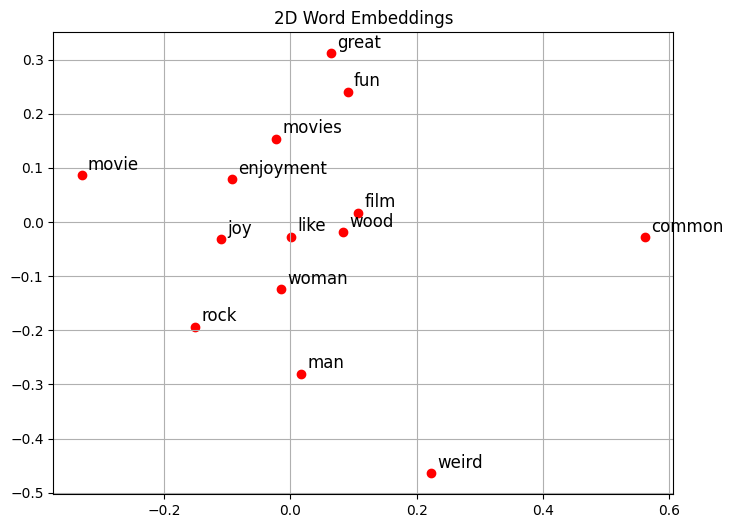

In [99]:
show_words_plot(sample_words, V_history[0])

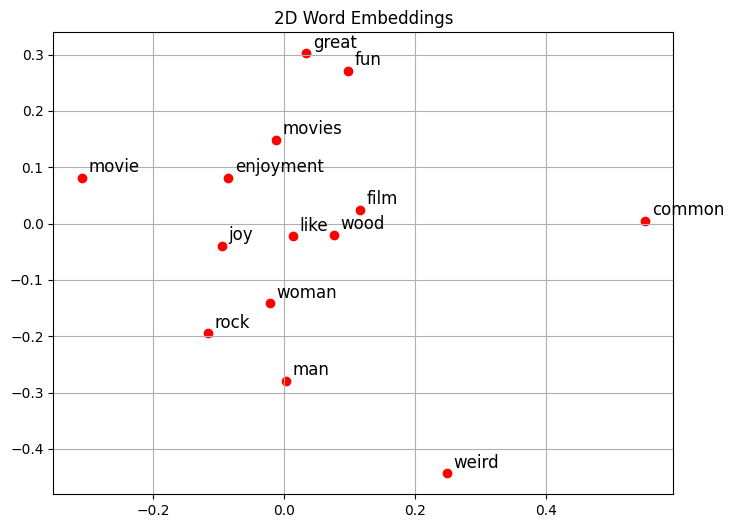

In [100]:
show_words_plot(sample_words, V_history[10])

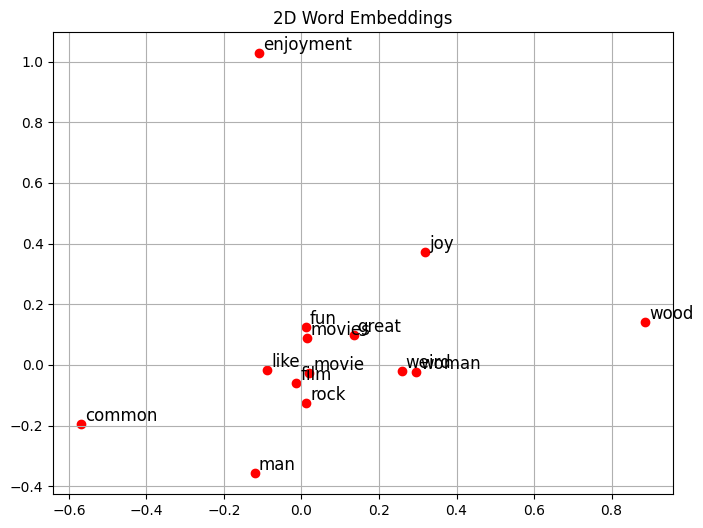

In [101]:
show_words_plot(sample_words, V_history[-1])

In [94]:
def cosine_similarity(vec1, vec2):
    return np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2))

In [95]:
def cosine_similarity_matrix(words, embeddings, word_to_id):
    n = len(words)
    matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            vec_i = embeddings[word_to_id[words[i]]]
            vec_j = embeddings[word_to_id[words[j]]]
            matrix[i, j] = cosine_similarity(vec_i, vec_j)
    return pd.DataFrame(matrix, index=words, columns=words)

In [102]:
similarity_before = cosine_similarity_matrix(sample_words, V_history[0], word_to_id)
similarity_after  = cosine_similarity_matrix(sample_words, V_history[-1], word_to_id)

In [103]:
print("Cosine Similarity BEFORE training:\n", similarity_before.round(2))
print("\nCosine Similarity AFTER training:\n", similarity_after.round(2))

Cosine Similarity BEFORE training:
            film  movie  movies  rock  wood  woman   man  like  enjoyment  \
film       1.00   0.12    0.02 -0.00 -0.11  -0.07 -0.14 -0.38      -0.46   
movie      0.12   1.00   -0.02  0.51 -0.23  -0.26 -0.39 -0.14      -0.34   
movies     0.02  -0.02    1.00 -0.10  0.46   0.33 -0.46  0.12       0.31   
rock      -0.00   0.51   -0.10  1.00 -0.04   0.27 -0.35  0.52      -0.27   
wood      -0.11  -0.23    0.46 -0.04  1.00   0.37  0.07 -0.24       0.02   
woman     -0.07  -0.26    0.33  0.27  0.37   1.00  0.19  0.30      -0.31   
man       -0.14  -0.39   -0.46 -0.35  0.07   0.19  1.00 -0.31      -0.20   
like      -0.38  -0.14    0.12  0.52 -0.24   0.30 -0.31  1.00       0.45   
enjoyment -0.46  -0.34    0.31 -0.27  0.02  -0.31 -0.20  0.45       1.00   
joy        0.04  -0.19    0.48  0.32  0.03   0.54 -0.39  0.61       0.11   
fun        0.09   0.11    0.12 -0.12 -0.13  -0.28 -0.08  0.03       0.13   
great      0.34  -0.12   -0.37  0.00 -0.28   0.25 -0